In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_PATH = next(
    (
        root / "data/raw/creditcard.csv"
        for root in (Path.cwd(), *Path.cwd().parents)
        if (root / "data/raw/creditcard.csv").exists()
    ),
    None,
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Download creditcard.csv as described in the README and place it in data/raw/."
    )

df = pd.read_csv(DATA_PATH)
df = df.sort_values("Time").reset_index(drop=True)

train_end = int(len(df) * 0.60)
validation_end = int(len(df) * 0.80)

train_df = df.iloc[:train_end].copy()
validation_df = df.iloc[train_end:validation_end].copy()
test_df = df.iloc[validation_end:].copy()

FEATURES = [column for column in df.columns if column != "Class"]

X_train = train_df[FEATURES]
y_train = train_df["Class"]

X_validation = validation_df[FEATURES]
y_validation = validation_df["Class"]

X_test = test_df[FEATURES]
y_test = test_df["Class"]

print(f"Training fraud cases:   {y_train.sum():,}")
print(f"Validation fraud cases: {y_validation.sum():,}")
print(f"Test fraud cases:       {y_test.sum():,}")

Training fraud cases:   360
Validation fraud cases: 57
Test fraud cases:       75


In [2]:
scale_features = ["Time", "Amount"]
pca_features = [f"V{i}" for i in range(1, 29)]

preprocessor = ColumnTransformer(
    transformers=[
        ("scaled", RobustScaler(), scale_features),
        ("pca", "passthrough", pca_features),
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logistic_model.fit(X_train, y_train)

logistic_scores = logistic_model.predict_proba(
    X_validation
)[:, 1]

In [3]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
class_ratio = negative_count / positive_count

xgb_unweighted = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_weighted = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=class_ratio,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_unweighted.fit(X_train, y_train)
xgb_weighted.fit(X_train, y_train)

xgb_unweighted_scores = xgb_unweighted.predict_proba(
    X_validation
)[:, 1]

xgb_weighted_scores = xgb_weighted.predict_proba(
    X_validation
)[:, 1]

In [4]:
def precision_recall_at_k(y_true, scores, k):
    y_array = np.asarray(y_true)
    scores_array = np.asarray(scores)

    ranked_indices = np.argsort(scores_array)[::-1]
    selected_indices = ranked_indices[:k]

    fraud_detected = y_array[selected_indices].sum()
    total_fraud = y_array.sum()

    return {
        "fraud_detected": int(fraud_detected),
        "precision_at_k": fraud_detected / k,
        "recall_at_k": fraud_detected / total_fraud,
    }

In [5]:
model_scores = {
    "Logistic regression": logistic_scores,
    "Unweighted XGBoost": xgb_unweighted_scores,
    "Class-weighted XGBoost": xgb_weighted_scores,
}

original_results = []

for model_name, scores in model_scores.items():
    capacity_metrics = precision_recall_at_k(
        y_validation,
        scores,
        100,
    )

    original_results.append(
        {
            "model": model_name,
            "average_precision": average_precision_score(
                y_validation,
                scores,
            ),
            **capacity_metrics,
        }
    )

original_results_df = pd.DataFrame(original_results)
original_results_df

,model,average_precision,fraud_detected,precision_at_k,recall_at_k
0,Logistic regression,0.772652,45,0.45,0.789474
1,Unweighted XGBoost,0.775894,44,0.44,0.771930
2,Class-weighted XGBoost,0.781009,44,0.44,0.771930


In [6]:
def stratified_bootstrap_indices(
    y_true,
    rng,
):
    y_array = np.asarray(y_true)

    legitimate_indices = np.flatnonzero(y_array == 0)
    fraud_indices = np.flatnonzero(y_array == 1)

    sampled_legitimate = rng.choice(
        legitimate_indices,
        size=len(legitimate_indices),
        replace=True,
    )

    sampled_fraud = rng.choice(
        fraud_indices,
        size=len(fraud_indices),
        replace=True,
    )

    sampled_indices = np.concatenate(
        [sampled_legitimate, sampled_fraud]
    )

    rng.shuffle(sampled_indices)

    return sampled_indices

In [7]:
N_BOOTSTRAPS = 1000
REVIEW_CAPACITY = 100

rng = np.random.default_rng(RANDOM_STATE)

y_validation_array = y_validation.to_numpy()

bootstrap_rows = []

for bootstrap_number in range(N_BOOTSTRAPS):
    sampled_indices = stratified_bootstrap_indices(
        y_validation_array,
        rng,
    )

    sampled_y = y_validation_array[sampled_indices]

    for model_name, scores in model_scores.items():
        sampled_scores = scores[sampled_indices]

        capacity_metrics = precision_recall_at_k(
            sampled_y,
            sampled_scores,
            REVIEW_CAPACITY,
        )

        bootstrap_rows.append(
            {
                "bootstrap": bootstrap_number,
                "model": model_name,
                "average_precision": average_precision_score(
                    sampled_y,
                    sampled_scores,
                ),
                "fraud_detected_at_100": (
                    capacity_metrics["fraud_detected"]
                ),
                "precision_at_100": (
                    capacity_metrics["precision_at_k"]
                ),
                "recall_at_100": (
                    capacity_metrics["recall_at_k"]
                ),
            }
        )

bootstrap_df = pd.DataFrame(bootstrap_rows)

bootstrap_df.head()

,bootstrap,model,average_precision,fraud_detected_at_100,precision_at_100,recall_at_100
0,0,Logistic regression,0.771547,44,0.44,0.771930
1,0,Unweighted XGBoost,0.768192,44,0.44,0.771930
2,0,Class-weighted XGBoost,0.767864,44,0.44,0.771930
3,1,Logistic regression,0.777831,45,0.45,0.789474
4,1,Unweighted XGBoost,0.788820,44,0.44,0.771930


In [8]:
def bootstrap_summary(
    bootstrap_results,
    metric,
):
    return (
        bootstrap_results.groupby("model")[metric]
        .agg(
            mean="mean",
            lower=lambda values: np.quantile(values, 0.025),
            upper=lambda values: np.quantile(values, 0.975),
        )
        .sort_values("mean", ascending=False)
    )

In [9]:
ap_summary = bootstrap_summary(
    bootstrap_df,
    "average_precision",
)

ap_summary

,mean,lower,upper
model,,,
Class-weighted XGBoost,0.780701,0.670266,0.878372
Unweighted XGBoost,0.776035,0.665204,0.874083
Logistic regression,0.772731,0.666629,0.870431


In [10]:
recall_summary = bootstrap_summary(
    bootstrap_df,
    "recall_at_100",
)

recall_summary

,mean,lower,upper
model,,,
Logistic regression,0.784842,0.684211,0.877193
Class-weighted XGBoost,0.771614,0.649123,0.877193
Unweighted XGBoost,0.771368,0.649123,0.877193


In [11]:
fraud_detected_summary = bootstrap_summary(
    bootstrap_df,
    "fraud_detected_at_100",
)

fraud_detected_summary

,mean,lower,upper
model,,,
Logistic regression,44.736,39.0,50.0
Class-weighted XGBoost,43.982,37.0,50.0
Unweighted XGBoost,43.968,37.0,50.0


In [12]:
ap_pivot = bootstrap_df.pivot(
    index="bootstrap",
    columns="model",
    values="average_precision",
)

ap_pivot["logistic_minus_unweighted_xgb"] = (
    ap_pivot["Logistic regression"]
    - ap_pivot["Unweighted XGBoost"]
)

ap_pivot["logistic_minus_weighted_xgb"] = (
    ap_pivot["Logistic regression"]
    - ap_pivot["Class-weighted XGBoost"]
)

In [13]:
def summarize_difference(values):
    values = np.asarray(values)

    return {
        "mean_difference": values.mean(),
        "lower_95": np.quantile(values, 0.025),
        "upper_95": np.quantile(values, 0.975),
        "probability_logistic_better": (values > 0).mean(),
    }


ap_difference_summary = pd.DataFrame(
    {
        "Logistic minus unweighted XGBoost":
            summarize_difference(
                ap_pivot[
                    "logistic_minus_unweighted_xgb"
                ]
            ),

        "Logistic minus weighted XGBoost":
            summarize_difference(
                ap_pivot[
                    "logistic_minus_weighted_xgb"
                ]
            ),
    }
).T

ap_difference_summary

,mean_difference,lower_95,upper_95,probability_logistic_better
Logistic minus unweighted XGBoost,-0.003304,-0.024231,0.015176,0.378
Logistic minus weighted XGBoost,-0.007970,-0.028890,0.010382,0.204


In [14]:
recall_pivot = bootstrap_df.pivot(
    index="bootstrap",
    columns="model",
    values="recall_at_100",
)

recall_pivot["logistic_minus_unweighted_xgb"] = (
    recall_pivot["Logistic regression"]
    - recall_pivot["Unweighted XGBoost"]
)

recall_pivot["logistic_minus_weighted_xgb"] = (
    recall_pivot["Logistic regression"]
    - recall_pivot["Class-weighted XGBoost"]
)

recall_difference_summary = pd.DataFrame(
    {
        "Logistic minus unweighted XGBoost":
            summarize_difference(
                recall_pivot[
                    "logistic_minus_unweighted_xgb"
                ]
            ),

        "Logistic minus weighted XGBoost":
            summarize_difference(
                recall_pivot[
                    "logistic_minus_weighted_xgb"
                ]
            ),
    }
).T

recall_difference_summary

,mean_difference,lower_95,upper_95,probability_logistic_better
Logistic minus unweighted XGBoost,0.013474,0.0,0.052632,0.483
Logistic minus weighted XGBoost,0.013228,0.0,0.052632,0.479


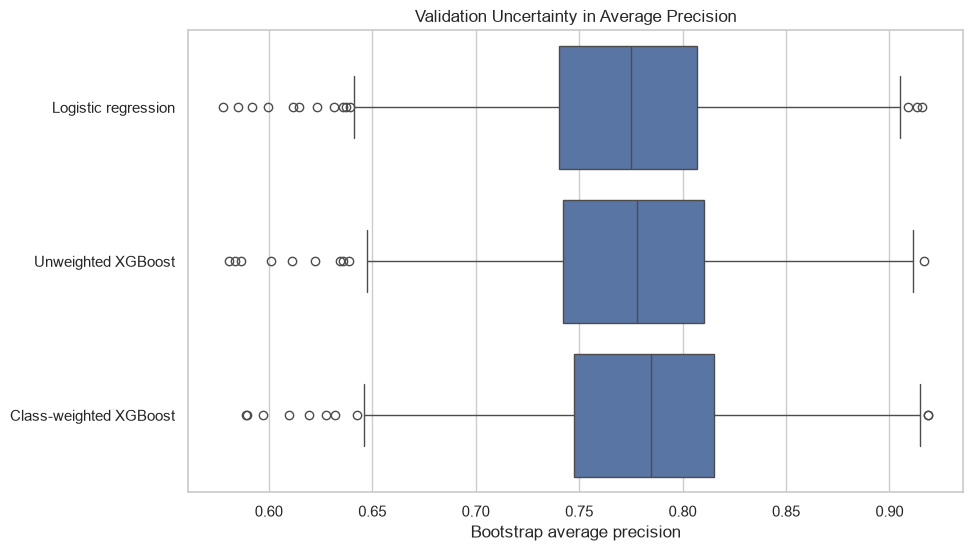

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=bootstrap_df,
    x="average_precision",
    y="model",
)

plt.xlabel("Bootstrap average precision")
plt.ylabel("")
plt.title("Validation Uncertainty in Average Precision")
plt.show()

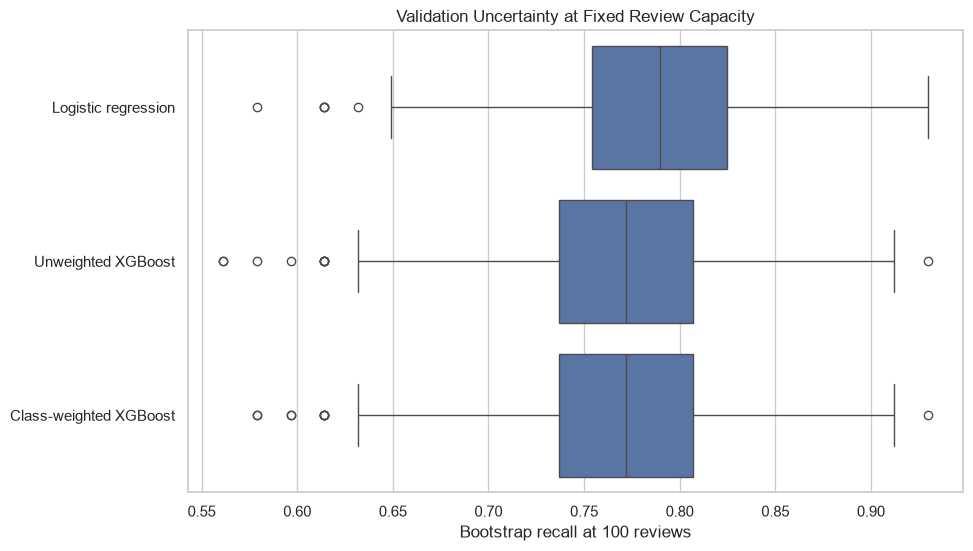

In [16]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=bootstrap_df,
    x="recall_at_100",
    y="model",
)

plt.xlabel("Bootstrap recall at 100 reviews")
plt.ylabel("")
plt.title("Validation Uncertainty at Fixed Review Capacity")
plt.show()

## Model-selection rule

The final model is selected primarily using average precision and recall at an
illustrative review capacity of 100 transactions. When performance differences
are small or uncertain, the simpler and more interpretable model is preferred.
The test set is not considered during model selection.

## Uncertainty and final model selection

Logistic regression and XGBoost continued to produce closely comparable rankings.
Paired bootstrap distributions and 95% percentile intervals below quantify the differences between logistic regression and both XGBoost alternatives.

At a review capacity of 100 transactions, logistic regression originally detected
45 of 57 validation fraud cases. Bootstrap estimates showed that its recall at this
capacity remained broadly comparable to both XGBoost alternatives.

Because the performance differences were small, the validation results do not establish a decisive advantage
for the more complex models. Logistic regression was therefore selected as the
final model due to its competitive ranking performance, interpretability and lower
implementation complexity.

The final operating policy will review the 100 highest-risk transactions in the
evaluation period. Both the model and the review capacity were selected before
examining test-set results.